In [128]:
import matplotlib.pyplot as plt
from matplotlib.image import imread
from mpl_toolkits import mplot3d
from matplotlib import gridspec
from PIL import Image
import io
from urllib.request import urlopen
# from lime import lime_image
from skimage.segmentation import mark_boundaries

from tqdm.notebook import tqdm
import numpy as np
import requests
import torch
import torch.nn as nn

from sklearn.metrics import classification_report, accuracy_score, f1_score

from torchvision import datasets, transforms

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [4]:
def train_on_batch(model, x_batch, y_batch, optimizer, loss_function):
    model.train()
    model.zero_grad()

    output = model(x_batch.to(device))

    loss = loss_function(output, y_batch.to(device))
    loss.backward()

    optimizer.step()
    return loss.cpu().item()

In [5]:
def train_epoch(train_generator, model, loss_function, optimizer, callback = None):
    epoch_loss = 0
    total = 0
    for it, (batch_of_x, batch_of_y) in enumerate(train_generator):
        batch_loss = train_on_batch(model, batch_of_x.to(device), batch_of_y.to(device), optimizer, loss_function)

        if callback is not None:
            callback(model, batch_loss)

        epoch_loss += batch_loss*len(batch_of_x)
        total += len(batch_of_x)

    return epoch_loss/total

In [6]:
def trainer(count_of_epoch,
            batch_size,
            dataset,
            model,
            loss_function,
            optimizer,
            lr = 0.001,
            callback = None):

    optima = optimizer(model.parameters(), lr=lr)

    iterations = tqdm(range(count_of_epoch), desc='epoch')
    iterations.set_postfix({'train epoch loss': np.nan})
    for it in iterations:
        batch_generator = tqdm(
            torch.utils.data.DataLoader(dataset=dataset, batch_size=batch_size, shuffle=True),
            leave=False, total=len(dataset)//batch_size+(len(dataset)%batch_size> 0))

        epoch_loss = train_epoch(train_generator=batch_generator,
                    model=model,
                    loss_function=loss_function,
                    optimizer=optima,
                    callback=callback)

        iterations.set_postfix({'train epoch loss': epoch_loss})

# Модель 

In [7]:
class CNN(torch.nn.Module):
    @property
    def device(self):
        for p in self.parameters():
            return p.device

    def __init__(self):
        super(CNN, self).__init__()

        self.layers = torch.nn.Sequential()
        self.layers.add_module('conv1', torch.nn.Conv2d(1, 1*6, kernel_size = 5))
        self.layers.add_module('relu1', torch.nn.ReLU())
        self.layers.add_module('pool1', torch.nn.MaxPool2d(kernel_size = 2))
        self.layers.add_module('conv2', torch.nn.Conv2d(1*6, 1*16, kernel_size = 5))
        self.layers.add_module('relu2', torch.nn.ReLU())
        self.layers.add_module('pool2', torch.nn.MaxPool2d(kernel_size = 2))
        self.layers.add_module('flatten', torch.nn.Flatten())
        self.layers.add_module('linear1', torch.nn.Linear(16*4*4, 120))
        self.layers.add_module('relu3', torch.nn.ReLU())
        self.layers.add_module('linear2', torch.nn.Linear(120, 84))
        self.layers.add_module('relu4', torch.nn.ReLU())
        self.layers.add_module('linear3', torch.nn.Linear(84, 10))

    def forward(self, input):
        return self.layers(input)

In [8]:
MNIST_train = datasets.MNIST('./mnist', train=True, download=True,
                             transform=transforms.ToTensor())

MNIST_test = datasets.MNIST('./mnist', train=False, download=True,
                            transform=transforms.ToTensor())

In [ ]:
loss_function = torch.nn.CrossEntropyLoss()
nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.Adam

class ImprovedCNN(nn.Module):
    def __init__(self):
        super(ImprovedCNN, self).__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # 28x28 -> 14x14

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # 14x14 -> 7x7

            nn.Flatten(),

            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.3), 

            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.layers(x)


model = ImprovedCNN()

model.to(device)

ImprovedCNN(
  (layers): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Flatten(start_dim=1, end_dim=-1)
    (9): Linear(in_features=3136, out_features=128, bias=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=128, out_features=10, bias=True)
  )
)

In [88]:
batch_generator = torch.utils.data.DataLoader(dataset = MNIST_test,
                                              batch_size=64)

pred = []
real = []
test_loss = 0
for it, (x_batch, y_batch) in enumerate(batch_generator):
    x_batch = x_batch.to(device)
    y_batch = y_batch.to(device)

    output = model(x_batch)

    test_loss += loss_function(output, y_batch).cpu().item()*len(x_batch)

    pred.extend(torch.argmax(output, dim=-1).cpu().numpy().tolist())
    real.extend(y_batch.cpu().numpy().tolist())

test_loss /= len(MNIST_test)

print('loss: {}'.format(test_loss))

loss: 3.5759626220703127


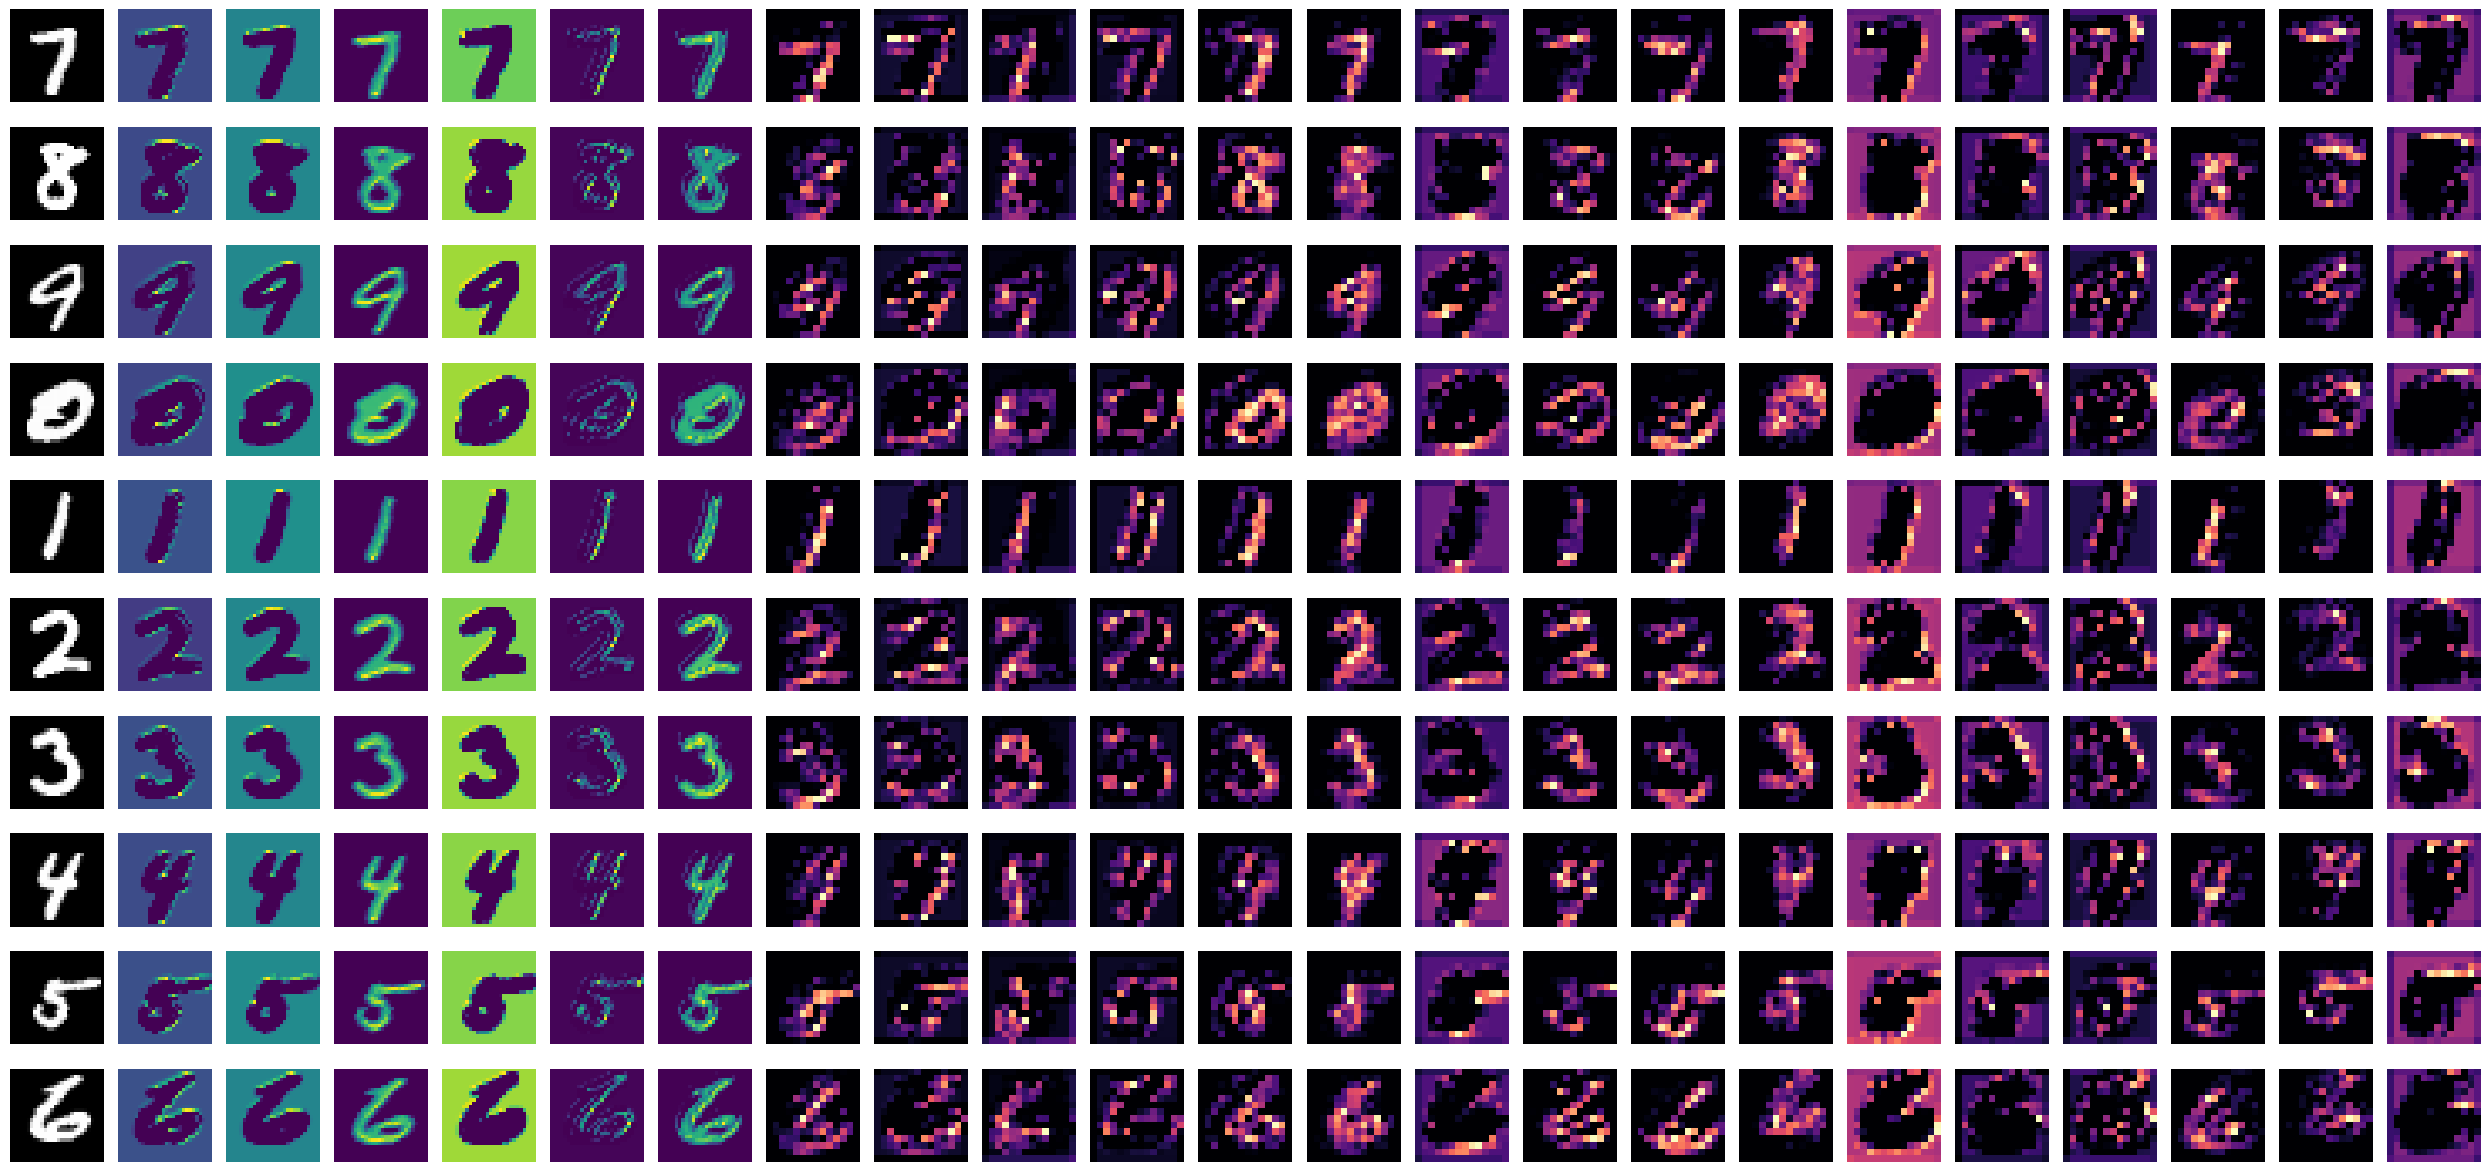

In [89]:
x = x_batch[-10:].to(device)
f1 = model.layers[0](x)
f1 = model.layers[1](f1)
y = model.layers[2](f1) 
f2 = model.layers[3](y)
f2 = model.layers[4](f2)
f2 = model.layers[5](f2) 
z = model.layers[6](f2)

fig = plt.figure(figsize=(25, 12))
gs = gridspec.GridSpec(10, 23)
for i in range(len(x)):
    # Оригинал
    ax0 = fig.add_subplot(gs[i, 0])
    ax0.imshow(x.cpu().detach()[i, 0].numpy(), cmap='gray')
    ax0.axis("off")
    for j in range(1, 7):
        ax = fig.add_subplot(gs[i, j])
        ax.imshow(y.cpu().detach()[i, j-1].numpy(), cmap='viridis')
        ax.axis("off")
    for j in range(7, 23):
        ax = fig.add_subplot(gs[i, j])
        ax.imshow(z.cpu().detach()[i, j-7].numpy(), cmap='magma')
        ax.axis("off")
plt.tight_layout()
plt.show()

In [126]:
trainer(count_of_epoch=4,
        batch_size=64,
        dataset=MNIST_train,
        model=model,
        loss_function=loss_function,
        optimizer=torch.optim.Adam,
        lr=0.001)

epoch:   0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

In [139]:
batch_generator = torch.utils.data.DataLoader(dataset = MNIST_test,
                                              batch_size=64)

pred = []
real = []
test_loss = 0
for it, (x_batch, y_batch) in enumerate(batch_generator):
    x_batch = x_batch.to(device)
    y_batch = y_batch.to(device)

    output = model(x_batch)

    test_loss += loss_function(output, y_batch).cpu().item()*len(x_batch)

    pred.extend(torch.argmax(output, dim=-1).cpu().numpy().tolist())
    real.extend(y_batch.cpu().numpy().tolist())

test_loss /= len(MNIST_test)
accuracy = accuracy_score(real, pred)
f1 = f1_score(real, pred, average='weighted')

print(f'Loss: {test_loss:.4f}')
print(f'Accuracy: {accuracy:.4%}')
print(f'F1-score: {f1:.4f}')

Loss: 0.0345
Accuracy: 99.0000%
F1-score: 0.9900


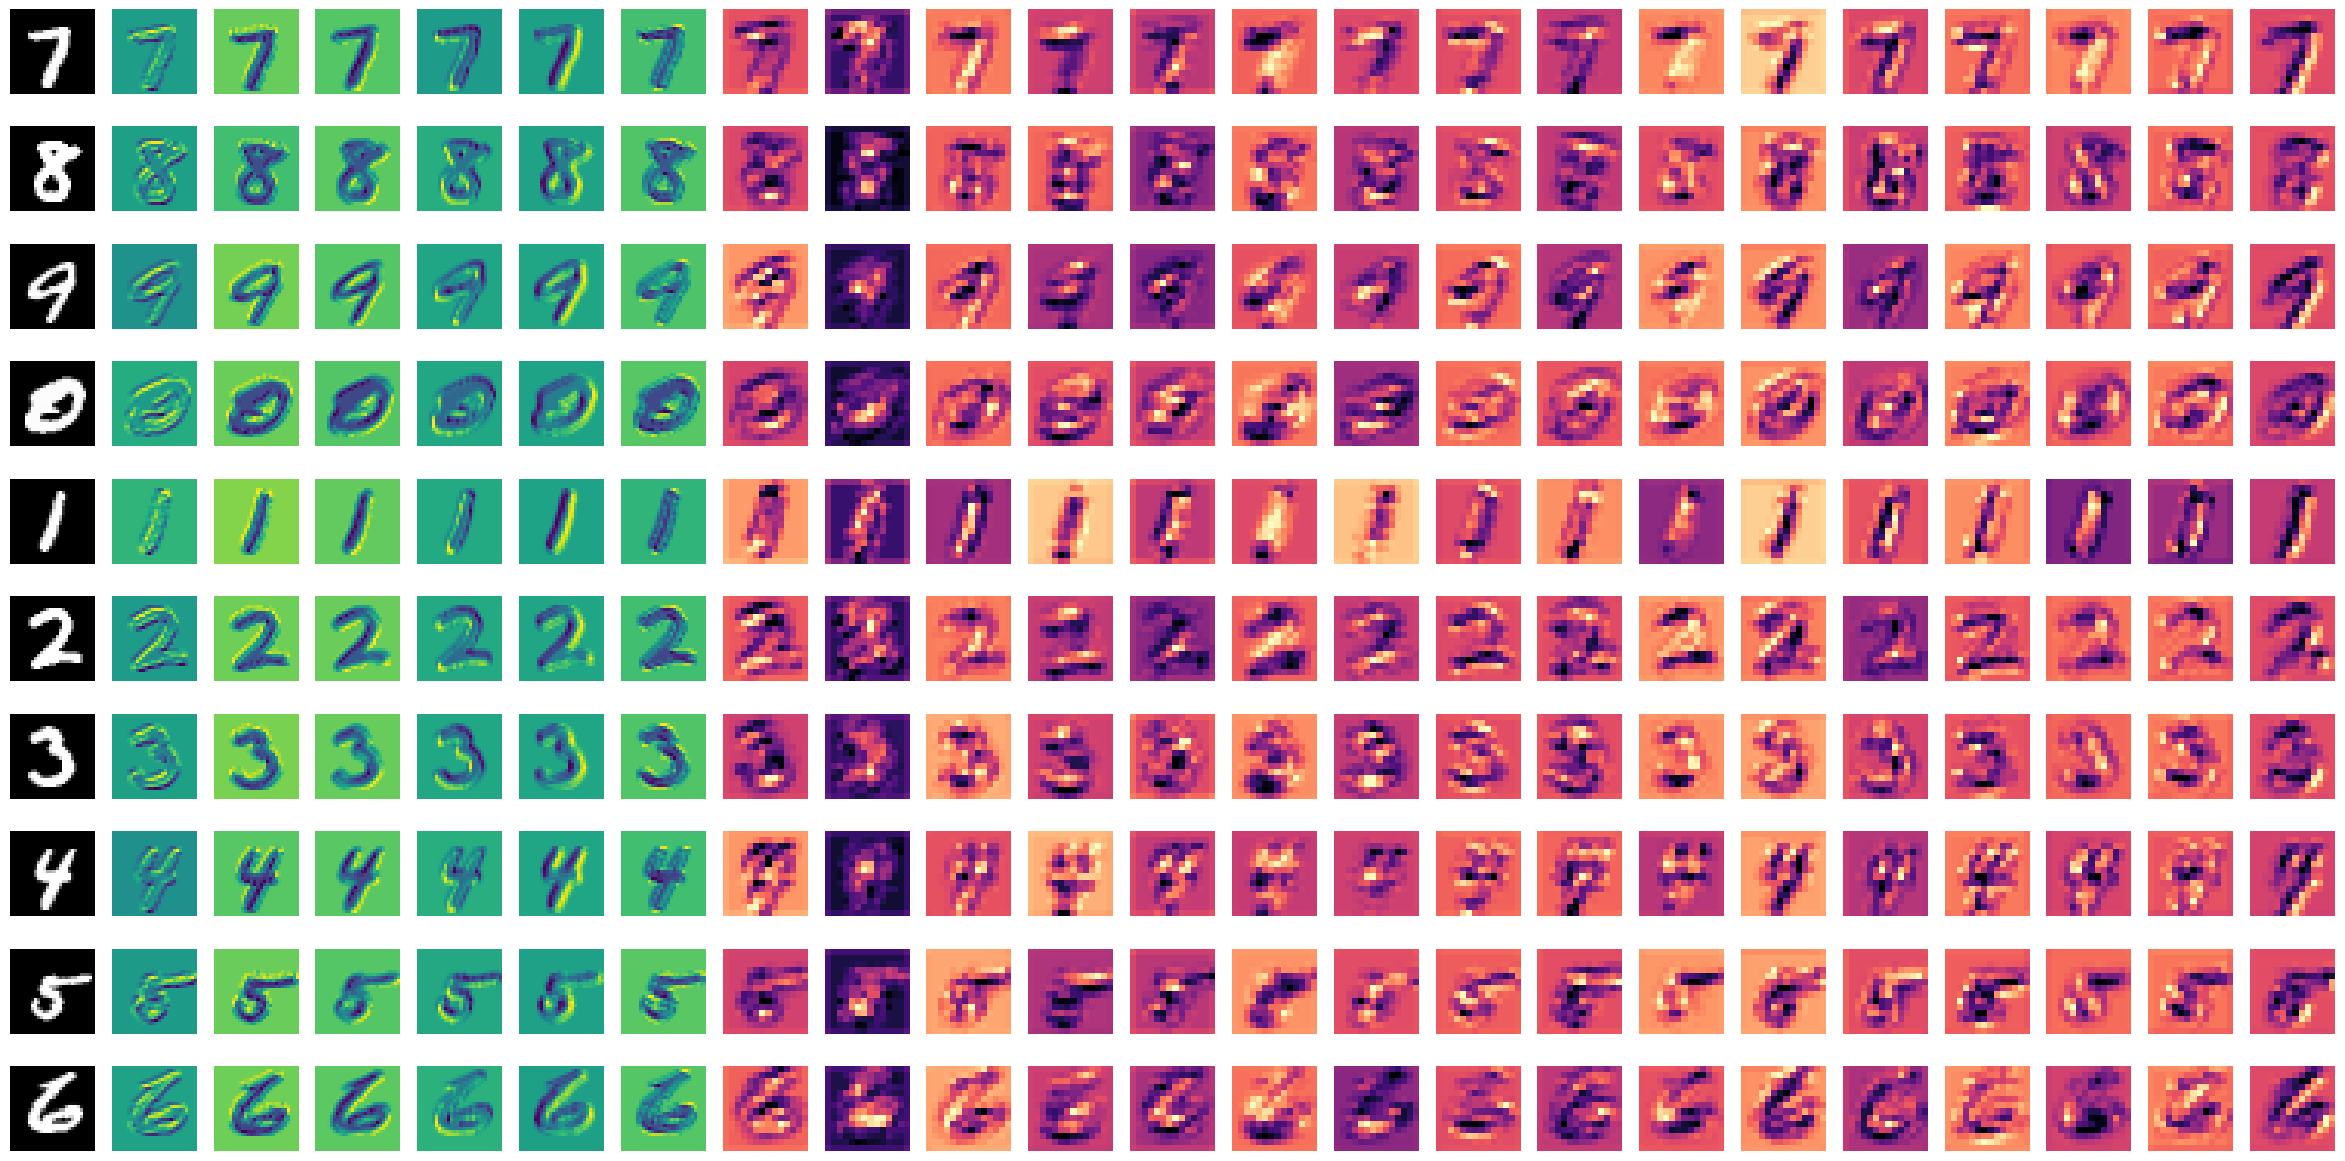

In [131]:
x = x_batch[-10:].to(device)

with torch.no_grad():
    y = model.layers[0](x)
    y_activated = model.layers[2](model.layers[1](y))
    y_pooled = model.layers[3](y_activated)
    z = model.layers[4](y_pooled) 
fig = plt.figure(figsize=(30, 15))
gs = gridspec.GridSpec(10, 23)

for i in range(len(x)):
    ax_orig = fig.add_subplot(gs[i, 0])
    ax_orig.imshow(x.cpu().detach()[i, 0].numpy(), cmap='gray')
    ax_orig.axis("off")
    for j in range(1, 7):
        ax = fig.add_subplot(gs[i, j])
        ax.imshow(y.cpu().detach()[i, j-1].numpy(), cmap='viridis')
        ax.axis("off")
    for j in range(7, 23):
        ax = fig.add_subplot(gs[i, j])
        ax.imshow(z.cpu().detach()[i, j-7].numpy(), cmap='magma')
        ax.axis("off")
plt.show()